# Oversampling

### Install Library

In [38]:
!pip install pandas matplotlib scikit-learn imbalanced-learn


### Load Dataset

In [47]:
import pandas as pd

# Load CSV
df = pd.read_csv("ecoli2.csv")
print()
print("="*80)
print(df.head())
print("="*80)

# Pisahkan fitur & target
X = df[["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2"]]
y = df["localization_class"].astype(str)

print()
print("="*60)
print("Shape fitur:", X.shape)
print("Shape target:", y.shape)
print("="*60)
print()
print("---Distribusi target:---\n")
print("="*60)
print(y.value_counts())
print("="*60)



   id protein_name   mcg   gvh   lip  chg   aac  alm1  alm2 localization_class
0   1    AAT_ECOLI  0.49  0.29  0.48  0.5  0.56  0.24  0.35                 cp
1   2   ACEA_ECOLI  0.07  0.40  0.48  0.5  0.54  0.35  0.44                 cp
2   3   ACEK_ECOLI  0.56  0.40  0.48  0.5  0.49  0.37  0.46                 cp
3   4   ACKA_ECOLI  0.59  0.49  0.48  0.5  0.52  0.45  0.36                 cp
4   5    ADI_ECOLI  0.23  0.32  0.48  0.5  0.55  0.25  0.35                 cp

Shape fitur: (336, 7)
Shape target: (336,)

---Distribusi target:---

localization_class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imS      2
imL      2
Name: count, dtype: int64


### Standarisasi Fitur

In [48]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("\n>>> Melakukan standardisasi fitur...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cek hasil standardisasi (statistik ringkas)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n=== Statistik setelah StandardScaler ===")
print(X_scaled_df.describe().T[["mean", "std"]])

print("\nContoh 5 baris pertama setelah scaling:")
print(X_scaled_df.head())



>>> Melakukan standardisasi fitur...

=== Statistik setelah StandardScaler ===
              mean       std
mcg   8.458842e-17  1.001491
gvh  -4.229421e-17  1.001491
lip  -6.767074e-16  1.001491
chg   1.797504e-16  1.001491
aac   8.458842e-17  1.001491
alm1 -1.691768e-16  1.001491
alm2 -4.863834e-16  1.001491

Contoh 5 baris pertama setelah scaling:
        mcg       gvh       lip       chg       aac      alm1      alm2
0 -0.051761 -1.419531 -0.175142 -0.054636  0.490781 -1.207717 -0.716084
1 -2.212876 -0.675967 -0.175142 -0.054636  0.327106 -0.697111 -0.285665
2  0.308424 -0.675967 -0.175142 -0.054636 -0.082081 -0.604273 -0.190016
3  0.462790 -0.067597 -0.175142 -0.054636  0.163431 -0.232923 -0.668259
4 -1.389594 -1.216741 -0.175142 -0.054636  0.408944 -1.161299 -0.716084


### Encode Target Kelas

LabelEncoder mengubah target string menjadi angka agar bisa digunakan algoritma ML. Dimana saya menampilkan mapping agar mudah diketahui kelas mana yang diwakili angka berapa.

In [49]:
from sklearn.preprocessing import LabelEncoder

# Encode target menjadi angka
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Tampilkan mapping kelas
print("Mapping kelas ke angka:")
for cls, val in zip(le.classes_, range(len(le.classes_))):
    print(f"{cls} -> {val}")


Mapping kelas ke angka:
cp -> 0
im -> 1
imL -> 2
imS -> 3
imU -> 4
om -> 5
omL -> 6
pp -> 7


### PCA ke 2 Dimensi

In [50]:
# ========================================
# PCA: Reduksi Dimensi 7D -> 2D
# ========================================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

print("\n>>> Melakukan PCA reduksi dari 7D ke 2D ...")

# Inisialisasi PCA ke 2 komponen utama
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)  # X_scaled = data fitur setelah standardisasi

# ------------------------------
# 1. Info Variansi
# ------------------------------
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()

print("\nProporsi variansi yang dijelaskan tiap komponen:")
print(explained_var)
print(f"Total variansi yang dijelaskan: {total_var:.2%}")

# Buat tabel untuk ringkasan variansi
df_var = pd.DataFrame({
    "Komponen": ["PC1", "PC2"],
    "Explained Variance Ratio": explained_var
})
print("\nTabel variansi tiap komponen:")
print(df_var)



>>> Melakukan PCA reduksi dari 7D ke 2D ...

Proporsi variansi yang dijelaskan tiap komponen:
[0.31508933 0.20874152]
Total variansi yang dijelaskan: 52.38%

Tabel variansi tiap komponen:
  Komponen  Explained Variance Ratio
0      PC1                  0.315089
1      PC2                  0.208742


### Scatter Plot PCA Data Asli

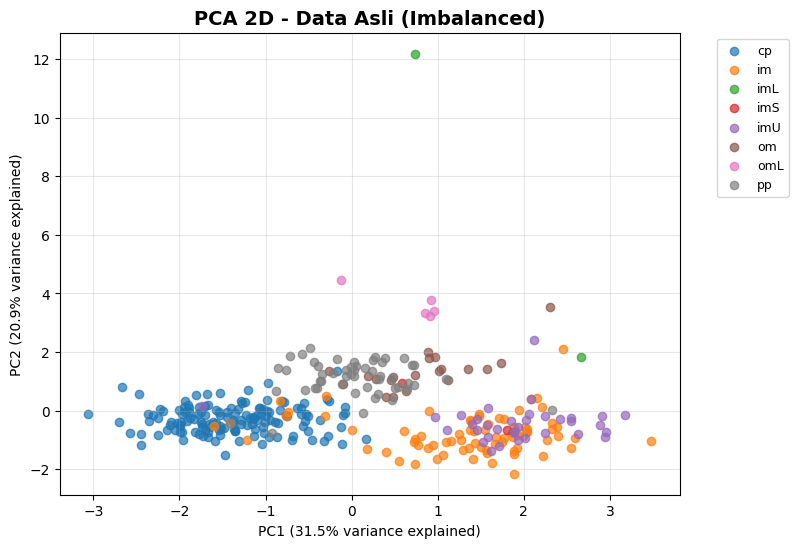

In [51]:
# Plot hasil PCA
plt.figure(figsize=(8, 6))

for cls in range(len(le.classes_)):  # le = LabelEncoder
    plt.scatter(
        X_pca[y_enc == cls, 0],
        X_pca[y_enc == cls, 1],
        alpha=0.7,
        label=le.classes_[cls]
    )

plt.title("PCA 2D - Data Asli (Imbalanced)", fontsize=14, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance explained)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance explained)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)

#### Menghitung jumlah sampel mayoritas & minoritas

Hasilnya pada mayoritas dan minoritas ini untuk nilai 0 adalah label numerik untuk kelas mayoritas (y_enc), yang biasanya hasil dari LabelEncoder dan angka 143 adalah jumlah sampel di kelas mayoritas tersebut. Begitu juga pada nilai 2 adalah label numerik untuk kelas minoritas dan angka 2 juga adalah jumlah sampel di kelas minoritas.

Jadi 0 dan 2 bukan jumlah, tapi kode/label kelas.

In [52]:
import numpy as np

# Hitung jumlah tiap kelas
classes, counts = np.unique(y_enc, return_counts=True)
major_class = classes[np.argmax(counts)]
minor_class = classes[np.argmin(counts)]

print("Mayoritas:", major_class, counts.max())
print("Minoritas:", minor_class, counts.min())

# Total sampel sintetis yang akan dibuat
G = counts.max() - counts.min()
print("Jumlah sampel sintetis yang akan dibuat:", G)


Mayoritas: 0 143
Minoritas: 2 2
Jumlah sampel sintetis yang akan dibuat: 141


### Melakukan penyeimbangan data menggunakan ADASYN/SMOTE

#### Distribusi Awal

In [53]:
# ========================================
# DISTRIBUSI AWAL
# ========================================
import pandas as pd
import numpy as np

print(">>> Mulai implementasi balancing data pada dataset E.coli")

print("\n=== DISTRIBUSI AWAL ===")
original_distribution = pd.Series(y).value_counts().sort_index()
print(original_distribution)

minority = original_distribution.min()
majority = original_distribution.max()
ratio = majority / minority
print(f"\nJumlah sampel terkecil: {minority}")
print(f"Rasio imbalance: {majority}/{minority} ≈ {ratio:.1f}:1")


>>> Mulai implementasi balancing data pada dataset E.coli

=== DISTRIBUSI AWAL ===
localization_class
cp     143
im      77
imL      2
imS      2
imU     35
om      20
omL      5
pp      52
Name: count, dtype: int64

Jumlah sampel terkecil: 2
Rasio imbalance: 143/2 ≈ 71.5:1


#### Mencoba Melakukan Balancing dengan ADASYN

In [54]:
# ========================================
# BALANCING DENGAN ADASYN
# ========================================
from imblearn.over_sampling import ADASYN
import time

try:
    print("\n>>> Mencoba ADASYN ...")
    start = time.time()
    adasyn = ADASYN(random_state=42, n_neighbors=1, sampling_strategy="not majority")
    X_res_ada, y_res_ada = adasyn.fit_resample(X_scaled, y)
    elapsed = time.time() - start
    print(f"Sukses ADASYN (waktu {elapsed:.2f}s)")

    dist_ada = pd.Series(y_res_ada).value_counts().sort_index()
    print("\n=== DISTRIBUSI SETELAH BALANCING (ADASYN) ===")
    print(dist_ada)

    before = len(y)
    after = len(y_res_ada)
    generated = after - before
    print("\n=== RINGKASAN ===")
    print(f"Jumlah data sebelum   : {before}")
    print(f"Jumlah data sesudah   : {after}")
    print(f"Data synthetic        : {generated} ({generated/after:.1%})")

except Exception as e:
    print(f"ADASYN gagal: {e}")



>>> Mencoba ADASYN ...
ADASYN gagal: Not any neigbours belong to the majority class. This case will induce a NaN case with a division by zero. ADASYN is not suited for this specific dataset. Use SMOTE instead.


#### Mencoba Melakukan Balancing Dengan Smote

In [55]:
# ========================================
# BALANCING DENGAN SMOTE
# ========================================
from imblearn.over_sampling import SMOTE

try:
    print("\n>>> Mencoba SMOTE ...")
    start = time.time()
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_res_smote, y_res_smote = smote.fit_resample(X_scaled, y)
    elapsed = time.time() - start
    print(f"Sukses SMOTE (waktu {elapsed:.2f}s)")

    dist_smote = pd.Series(y_res_smote).value_counts().sort_index()
    print("\n=== DISTRIBUSI SETELAH BALANCING (SMOTE) ===")
    print(dist_smote)

    before = len(y)
    after = len(y_res_smote)
    generated = after - before
    print("\n=== RINGKASAN ===")
    print(f"Jumlah data sebelum   : {before}")
    print(f"Jumlah data sesudah   : {after}")
    print(f"Data synthetic        : {generated} ({generated/after:.1%})")

except Exception as e:
    print(f"SMOTE gagal: {e}")



>>> Mencoba SMOTE ...
Sukses SMOTE (waktu 0.01s)

=== DISTRIBUSI SETELAH BALANCING (SMOTE) ===
localization_class
cp     143
im     143
imL    143
imS    143
imU    143
om     143
omL    143
pp     143
Name: count, dtype: int64

=== RINGKASAN ===
Jumlah data sebelum   : 336
Jumlah data sesudah   : 1144
Data synthetic        : 808 (70.6%)


### Plotting Data Setelah Balancing dengan PCA


>>> Visualisasi hasil balancing dengan PCA ...


/tmp/ipykernel_6267/1594950854.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap("tab10", len(class_names))


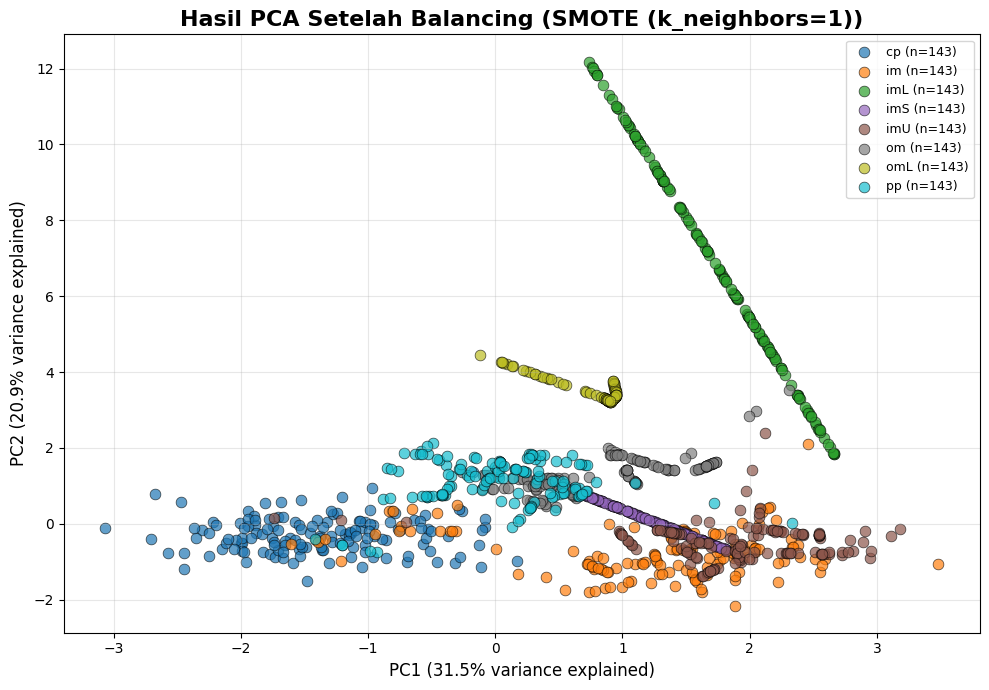

In [56]:
# ========================================
# PLOTTING DATA SETELAH BALANCING (PCA)
# ========================================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("\n>>> Visualisasi hasil balancing dengan PCA ...")

# Gunakan PCA yg sudah fit ke data asli
# (kalau belum ada, fit dulu di X_scaled)
pca = PCA(n_components=2, random_state=42)
pca.fit(X_scaled)  

# Transform hasil balancing ke ruang PCA yang sama
X_resampled_pca = pca.transform(X_resampled)

# Ambil nama kelas unik
class_names = sorted(pd.Series(y_resampled).unique())

# Warna otomatis untuk tiap kelas
color_map = plt.cm.get_cmap("tab10", len(class_names))

plt.figure(figsize=(10, 7))
for idx, class_name in enumerate(class_names):
    mask = (y_resampled == class_name)
    plt.scatter(
        X_resampled_pca[mask, 0],
        X_resampled_pca[mask, 1],
        c=[color_map(idx)],
        label=f"{class_name} (n={np.sum(mask)})",
        alpha=0.7,
        s=60,
        edgecolors="black",
        linewidth=0.5
    )

plt.title(f"Hasil PCA Setelah Balancing ({method_used})", fontsize=16, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance explained)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance explained)", fontsize=12)
plt.legend(loc="best", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Perbandingan Distribusi Kelas Sebelum dan Sesudah SMOTE

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Oversampling dengan SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)
X_smote, y_smote = smote.fit_resample(X, y_enc)

# Distribusi kelas sebelum dan sesudah
classes_before, counts_before = np.unique(y_enc, return_counts=True)
classes_after, counts_after = np.unique(y_smote, return_counts=True)

# Buat DataFrame perbandingan
df_compare = pd.DataFrame({
    "Kelas": le.inverse_transform(classes_before),
    "Jumlah Sebelum": counts_before,
    "Jumlah Sesudah": counts_after
})

# Tampilkan tabel distribusi
print("\nTabel Distribusi Kelas Sebelum dan Sesudah SMOTE:")
print(df_compare)




Tabel Distribusi Kelas Sebelum dan Sesudah SMOTE:
  Kelas  Jumlah Sebelum  Jumlah Sesudah
0    cp             143             143
1    im              77             143
2   imL               2             143
3   imS               2             143
4   imU              35             143
5    om              20             143
6   omL               5             143
7    pp              52             143



>>> Membuat perbandingan PCA & Distribusi Kelas ...


/tmp/ipykernel_6267/3371108576.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap("tab10", len(class_names))


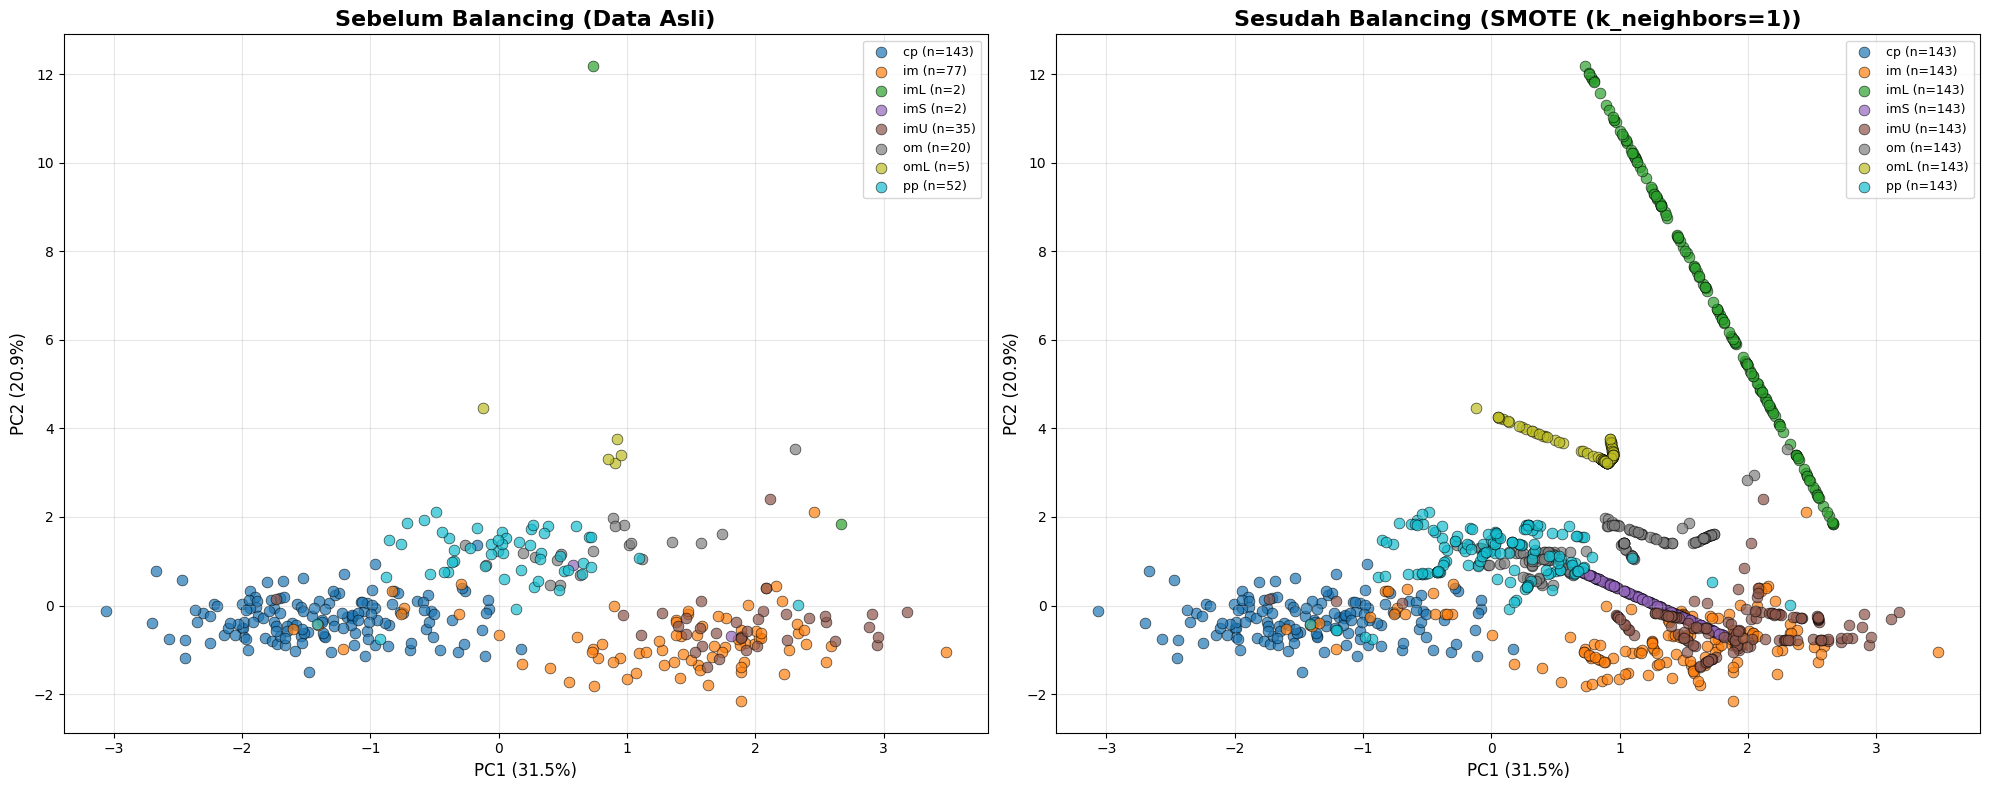


>>> Membuat diagram batang distribusi kelas ...


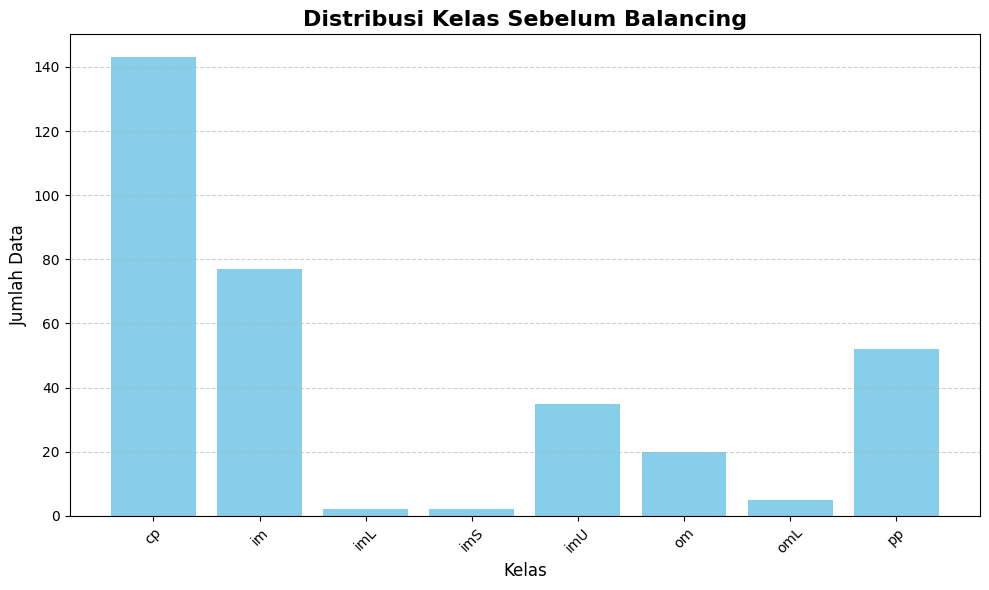

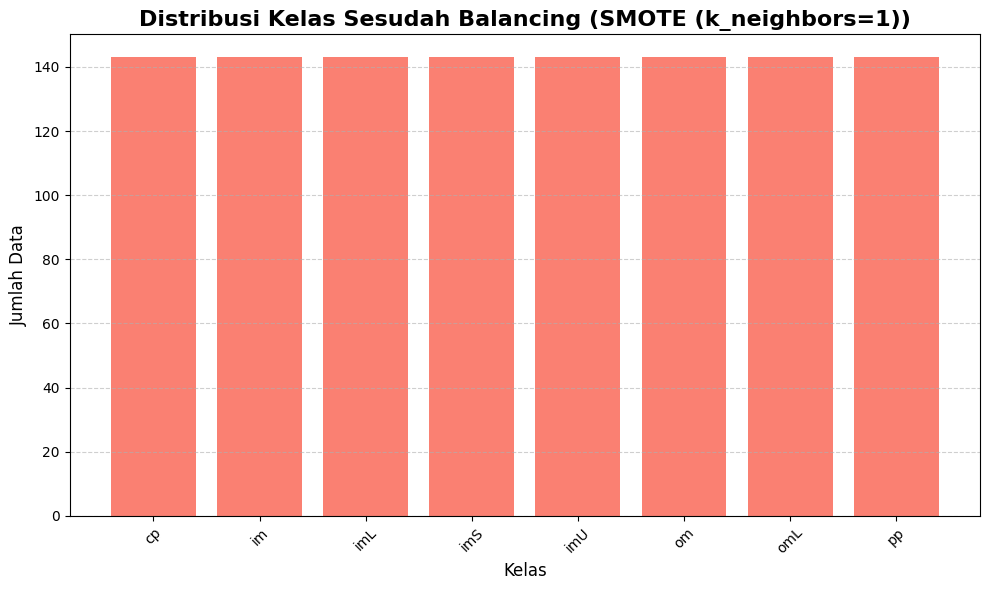

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

print("\n>>> Membuat perbandingan PCA & Distribusi Kelas ...")

# Fit PCA dari data asli 
pca = PCA(n_components=2, random_state=42)
pca.fit(X_scaled)

# Transform ke ruang PCA yang sama
X_pca_before = pca.transform(X_scaled)
X_pca_after  = pca.transform(X_resampled)

# Kelas unik
class_names = sorted(pd.Series(y).unique())
color_map = plt.cm.get_cmap("tab10", len(class_names))

# =====================================================
# Scatter PCA sebelum & sesudah balancing
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# ---------------------------
# Plot sebelum balancing
# ---------------------------
ax1.set_title("Sebelum Balancing (Data Asli)", fontsize=16, fontweight="bold")
for idx, class_name in enumerate(class_names):
    mask = (y == class_name)
    ax1.scatter(
        X_pca_before[mask, 0],
        X_pca_before[mask, 1],
        c=[color_map(idx)],
        label=f"{class_name} (n={np.sum(mask)})",
        alpha=0.7,
        s=60,
        edgecolors="black",
        linewidth=0.5
    )
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# ---------------------------
# Plot sesudah balancing
# ---------------------------
ax2.set_title(f"Sesudah Balancing ({method_used})", fontsize=16, fontweight="bold")
for idx, class_name in enumerate(class_names):
    mask = (y_resampled == class_name)
    ax2.scatter(
        X_pca_after[mask, 0],
        X_pca_after[mask, 1],
        c=[color_map(idx)],
        label=f"{class_name} (n={np.sum(mask)})",
        alpha=0.7,
        s=60,
        edgecolors="black",
        linewidth=0.5
    )
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# =====================================================
# Diagram batang distribusi kelas 
# =====================================================
print("\n>>> Membuat diagram batang distribusi kelas ...")

dist_before = pd.Series(y).value_counts().sort_index()
dist_after  = pd.Series(y_resampled).value_counts().sort_index()

# Plot Sebelum
plt.figure(figsize=(10, 6))
plt.bar(dist_before.index, dist_before.values, color="skyblue")
plt.title("Distribusi Kelas Sebelum Balancing", fontsize=16, fontweight="bold")
plt.xlabel("Kelas", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Sesudah
plt.figure(figsize=(10, 6))
plt.bar(dist_after.index, dist_after.values, color="salmon")
plt.title(f"Distribusi Kelas Sesudah Balancing ({method_used})", fontsize=16, fontweight="bold")
plt.xlabel("Kelas", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
